## 📊 Project: Customer Churn Analysis

### Objective:
Analyze customer churn and identify key factors leading to customer loss.

### Business Goal:
Reduce churn and minimize revenue loss.

## 📁 Data Description

The dataset contains 7,043 customers with 21 features including demographic information, subscribed services, account details, and churn status.

🔹 Customer Information:
- customerID: Unique identifier for each customer
- gender: Customer gender (Male/Female)
- SeniorCitizen: Whether the customer is a senior citizen (1 = Yes, 0 = No)
- Partner: Whether the customer has a partner (Yes/No)
- Dependents: Whether the customer has dependents (Yes/No)

🔹 Account Information:
- tenure: Number of months the customer has stayed with the company
- Contract: Type of contract (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer uses paperless billing (Yes/No)
- PaymentMethod: Customer’s payment method

🔹 Services Subscribed:
- PhoneService: Whether the customer has phone service
- MultipleLines: Whether the customer has multiple lines
- InternetService: Type of internet service (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security
- OnlineBackup: Whether the customer has online backup
- DeviceProtection: Whether the customer has device protection
- TechSupport: Whether the customer has tech support
- StreamingTV: Whether the customer uses streaming TV
- StreamingMovies: Whether the customer uses streaming movies

🔹 Charges:
- MonthlyCharges: Monthly amount charged to the customer
- TotalCharges: Total amount charged to the customer

🔹 Target Variable:
- Churn: Whether the customer left the company (Yes/No)

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [211]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [212]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [213]:
df.shape

(7043, 21)

In [214]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [216]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [217]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [218]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [219]:
df.duplicated().sum()

np.int64(0)

### Initial Observations:
- TotalCharges is object type and may contain empty strings → needs conversion to float
- Churn is Yes/No → will need encoding for analysis
- Data does not have missing values (clean dataset)
- Data does not have duplicated values
- Drop customer_id because it does not ues in analysis
- Some columns are categorical (Contract, PaymentMethod, etc.) → may need visualization using countplots/barplots


### Data Cleaning


In [220]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [221]:
df_clean = df.copy()

In [222]:
df_clean.drop(columns=["customerID","gender"],inplace=True)

In [223]:
df_clean.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='object')

In [224]:
#convert TotalCharges from object to float
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

In [225]:
df_clean['TotalCharges'].dtype

dtype('float64')

In [226]:
df_clean['TotalCharges'].isnull().sum()

np.int64(11)

In [227]:
#drop null as this has only small number of missing values
df_clean.dropna(inplace=True)

In [228]:
df_clean['TotalCharges'].isnull().sum()

np.int64(0)

In [229]:
df.duplicated().sum()

np.int64(0)

In [230]:
categorical_cols = df_clean.select_dtypes(include='object').columns
categorical_cols

Index(['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [231]:
for col in categorical_cols:
    print(f"Value counts for column: {col}")
    print(df_clean[col].value_counts())
    print("-"*40)  

Value counts for column: Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64
----------------------------------------
Value counts for column: Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
----------------------------------------
Value counts for column: PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
----------------------------------------
Value counts for column: MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
----------------------------------------
Value counts for column: InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
----------------------------------------
Value counts for column: OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
----------------------------------------
Val

In [232]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes':1, 'No':0})

In [233]:
df_clean = pd.get_dummies(df_clean, columns=['MultipleLines','OnlineSecurity',
                                 'OnlineBackup','DeviceProtection','TechSupport','Contract','StreamingTV','StreamingMovies','PaymentMethod','InternetService'])

In [234]:
df_clean.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,1,29.85,29.85,0,False,...,True,False,False,False,False,True,False,True,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,True,False,False,False,False,False,True,True,False,False
2,0,0,0,2,1,1,53.85,108.15,1,True,...,True,False,False,False,False,False,True,True,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,True,False,False,True,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,1,True,...,True,False,False,False,False,True,False,False,True,False


In [235]:
df_clean.shape

(7032, 40)

In [236]:
df_clean.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
 

In [237]:
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col} has {outliers.shape[0]} outliers")

tenure has 0 outliers
MonthlyCharges has 0 outliers
TotalCharges has 0 outliers


### Summary of data cleaning phase
- I remove customer_id and gender because they do not use in alaysis
- I convert TotalCharges from object to number
- When i convert TotalCharges from object to number they are some missing value (ll nulls) so this is small number so i decide to delete them
- There is no duplicates
- There is no outliers
- I make encoding for categrical columns
  

### EDA

In [238]:
df_clean.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,1,29.85,29.85,0,False,...,True,False,False,False,False,True,False,True,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,True,False,False,False,False,False,True,True,False,False
2,0,0,0,2,1,1,53.85,108.15,1,True,...,True,False,False,False,False,False,True,True,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,True,False,False,True,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,1,True,...,True,False,False,False,False,True,False,False,True,False


In [239]:
df_clean.info()          
 

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7032 non-null   int64  
 1   Partner                                  7032 non-null   int64  
 2   Dependents                               7032 non-null   int64  
 3   tenure                                   7032 non-null   int64  
 4   PhoneService                             7032 non-null   int64  
 5   PaperlessBilling                         7032 non-null   int64  
 6   MonthlyCharges                           7032 non-null   float64
 7   TotalCharges                             7032 non-null   float64
 8   Churn                                    7032 non-null   int64  
 9   MultipleLines_No                         7032 non-null   bool   
 10  MultipleLines_No phone service           7032 non-nul

In [240]:
df_clean.describe()      

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


In [241]:
df_clean.isnull().sum() 

SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSecurity_Yes                         0
OnlineBackup_No                            0
OnlineBackup_No internet service           0
OnlineBackup_Yes                           0
DeviceProtection_No                        0
DeviceProtection_No internet service       0
DeviceProtection_Yes                       0
TechSupport_No                             0
TechSuppor

In [242]:
binary_cols = ['SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
    print(f"{col} vs Churn:")
    print(pd.crosstab(df_clean[col], df_clean['Churn'], normalize='index'))
    print("-"*30)

SeniorCitizen vs Churn:
Churn                 0         1
SeniorCitizen                    
0              0.763497  0.236503
1              0.583187  0.416813
------------------------------
Partner vs Churn:
Churn           0         1
Partner                    
0        0.670239  0.329761
1        0.802829  0.197171
------------------------------
Dependents vs Churn:
Churn              0         1
Dependents                    
0           0.687209  0.312791
1           0.844688  0.155312
------------------------------
PhoneService vs Churn:
Churn                0         1
PhoneService                    
0             0.750000  0.250000
1             0.732525  0.267475
------------------------------
PaperlessBilling vs Churn:
Churn                    0         1
PaperlessBilling                    
0                 0.836243  0.163757
1                 0.664107  0.335893
------------------------------


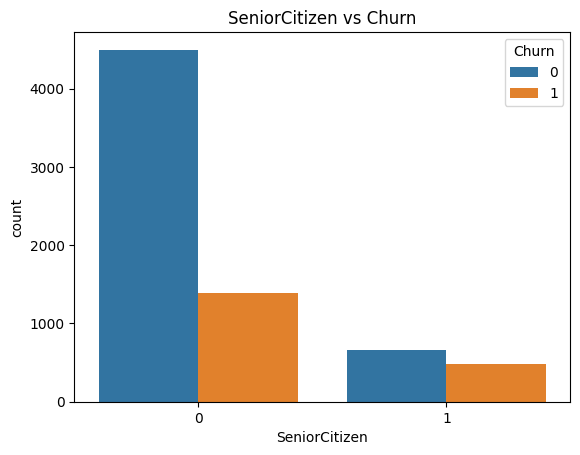

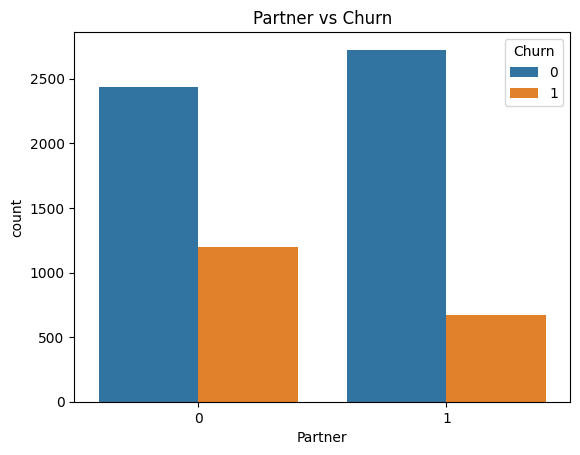

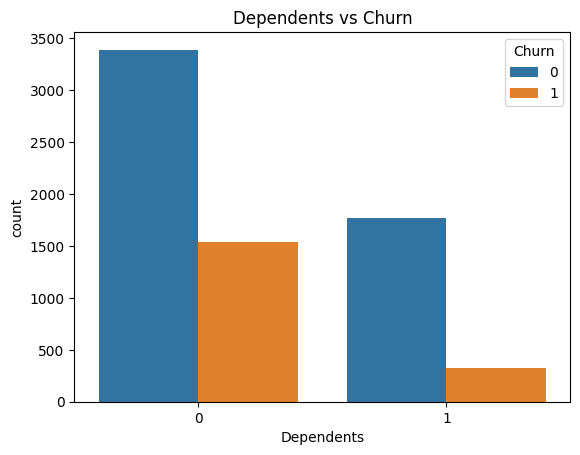

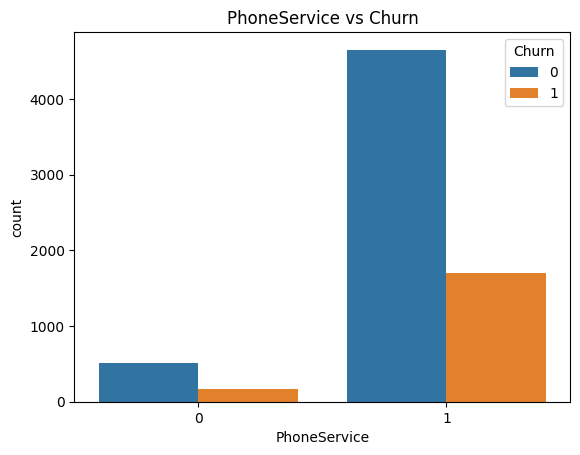

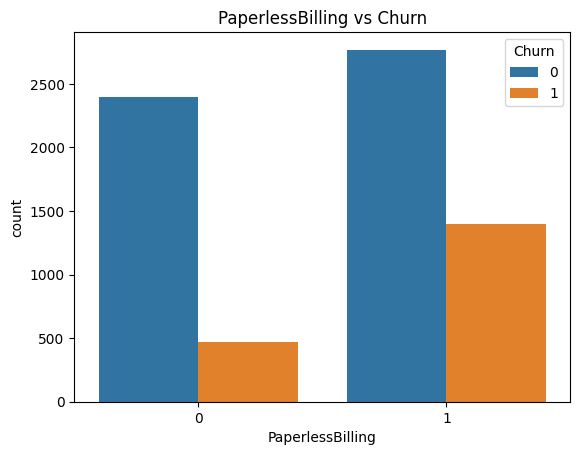

In [243]:
for col in binary_cols:
    sns.countplot(x=col, hue='Churn', data=df_clean)
    plt.title(f"{col} vs Churn")
    plt.show()

In [244]:
multi_cols = ['MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No'] 

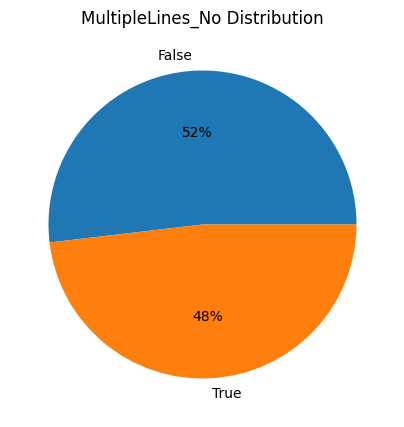

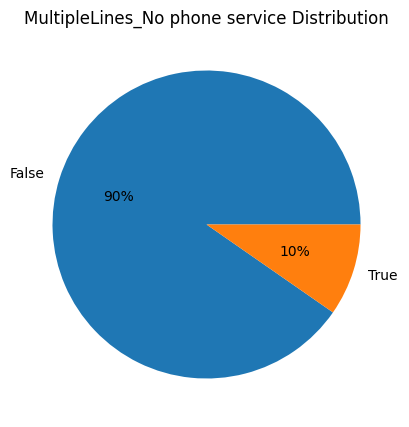

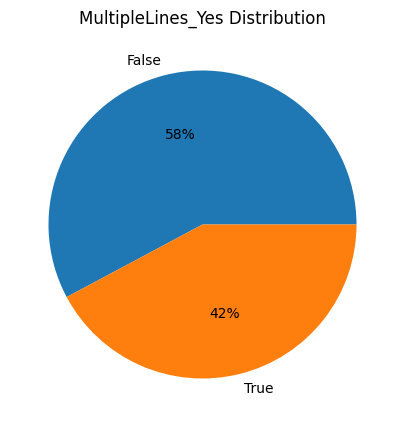

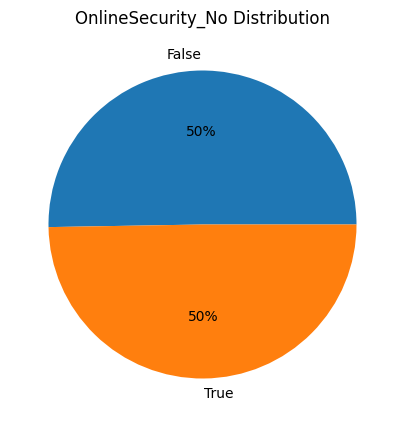

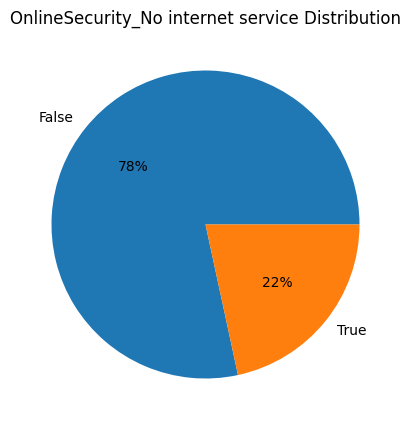

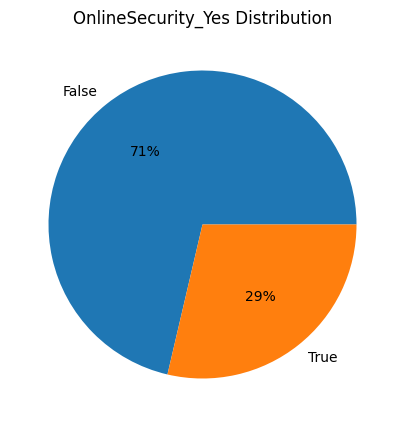

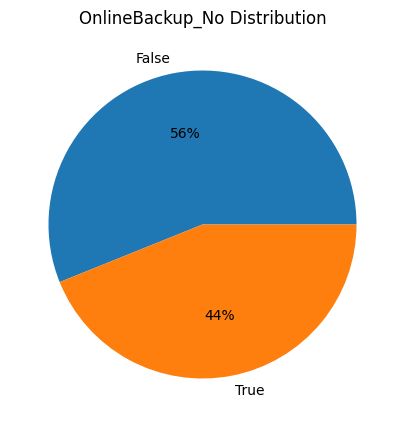

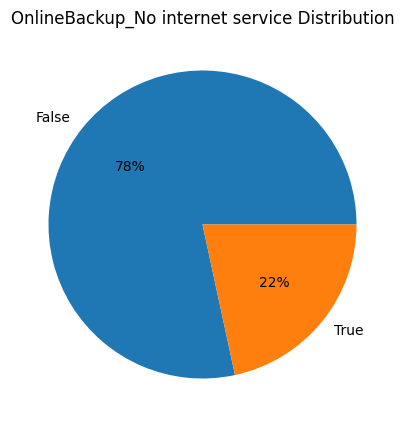

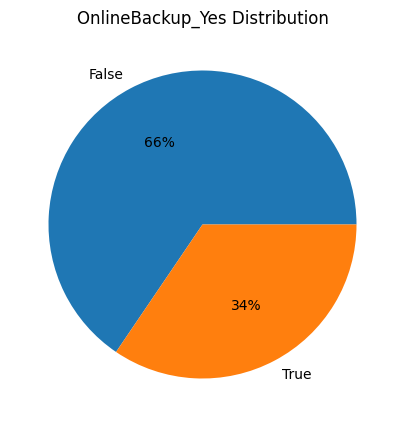

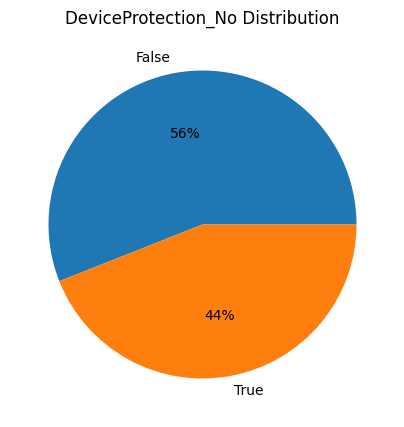

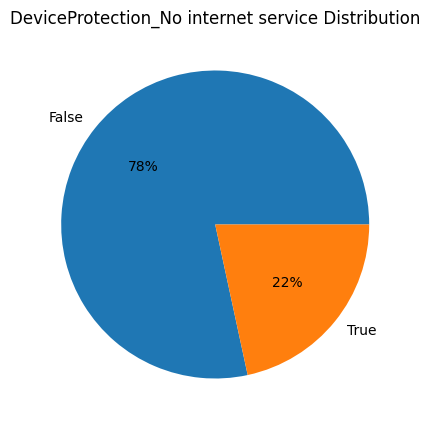

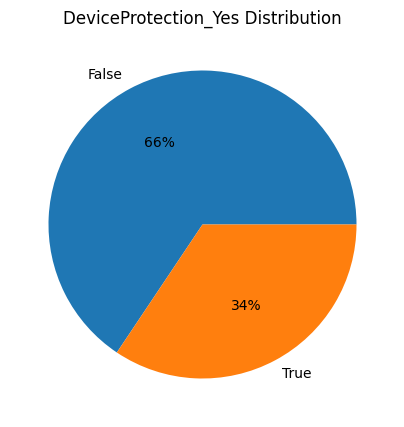

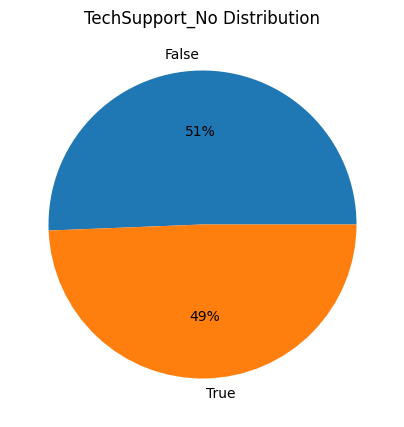

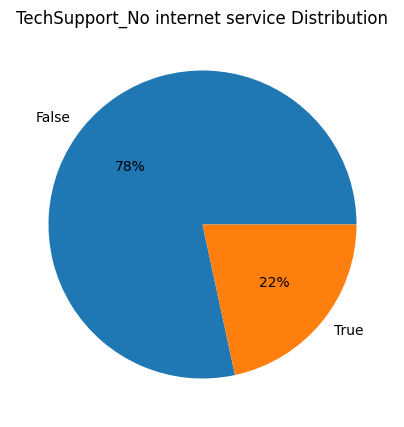

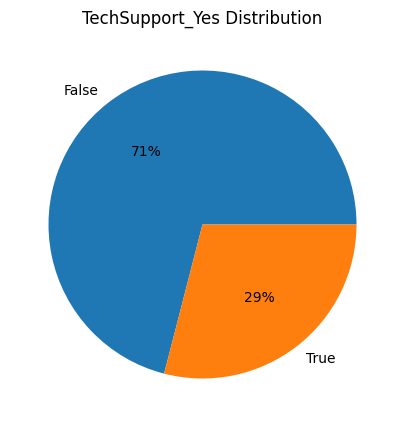

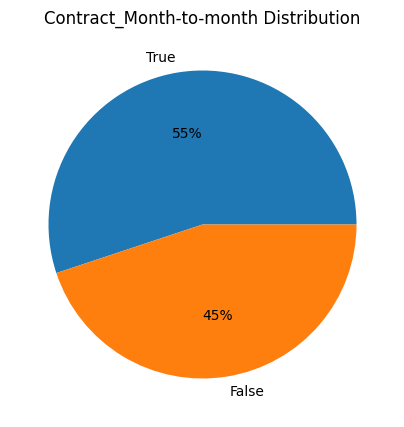

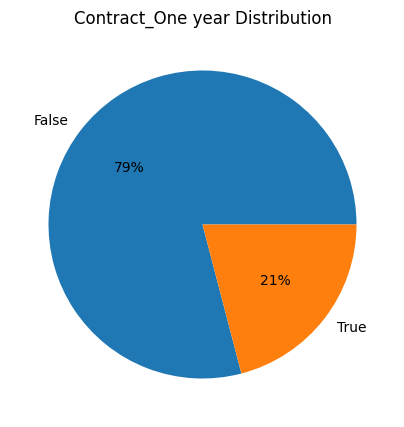

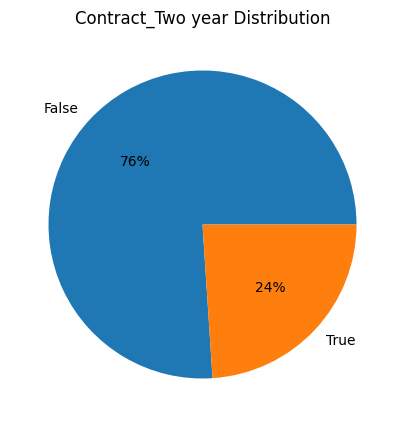

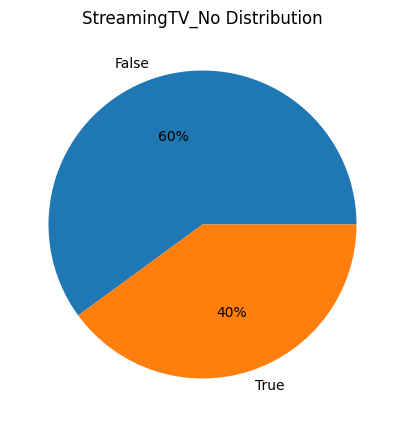

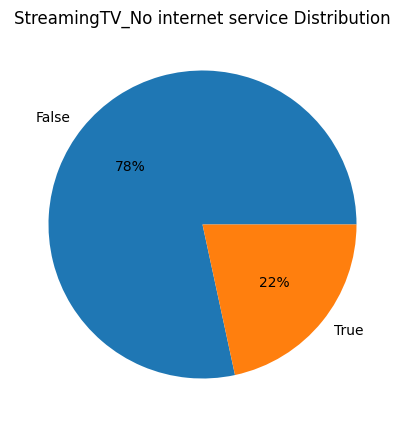

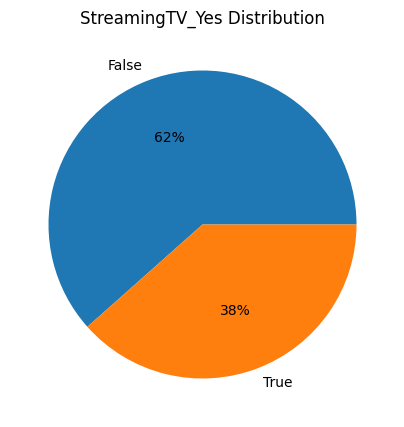

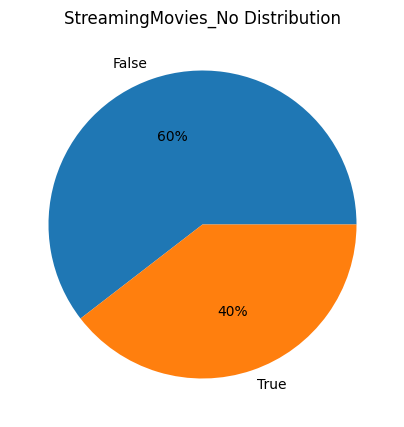

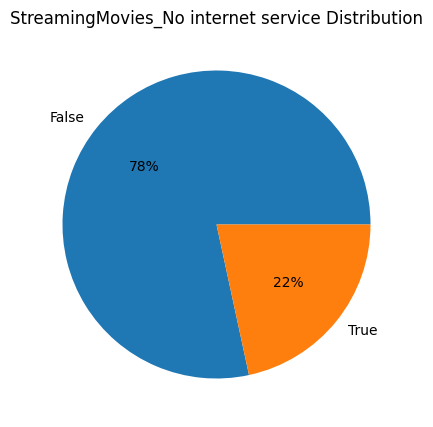

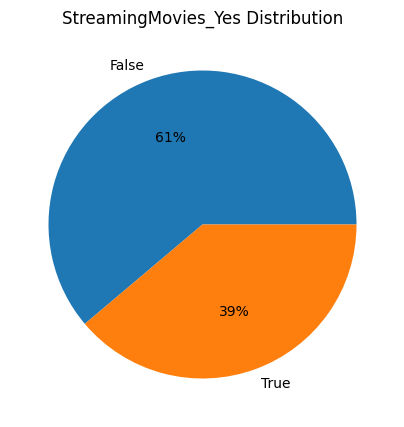

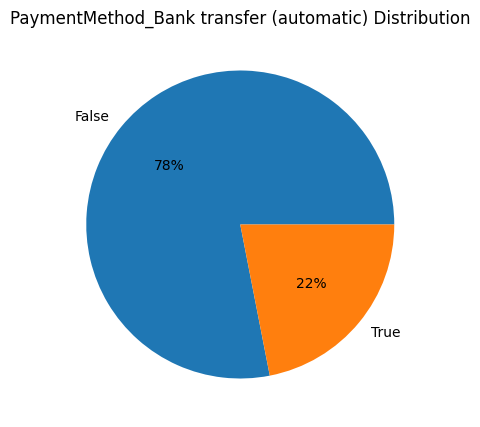

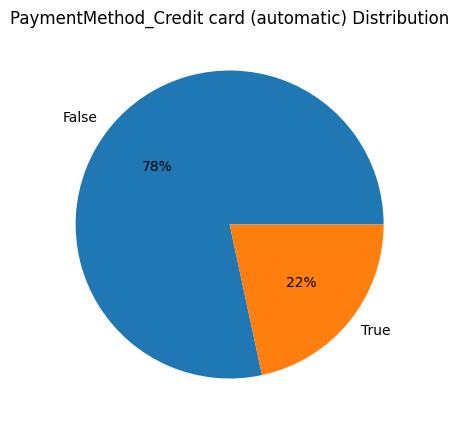

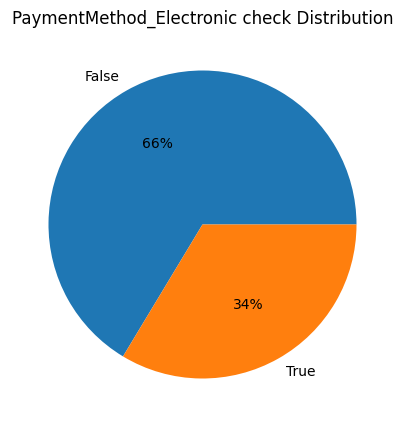

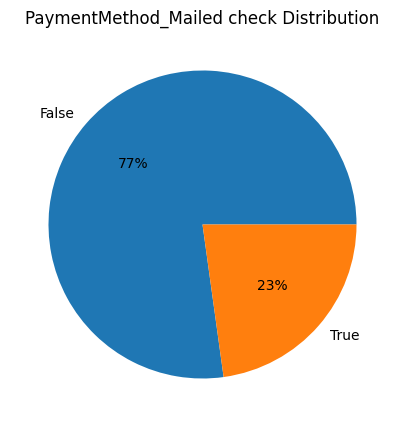

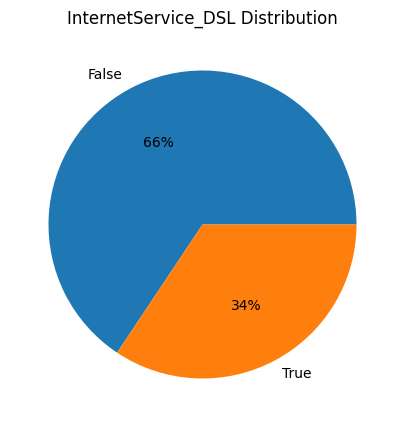

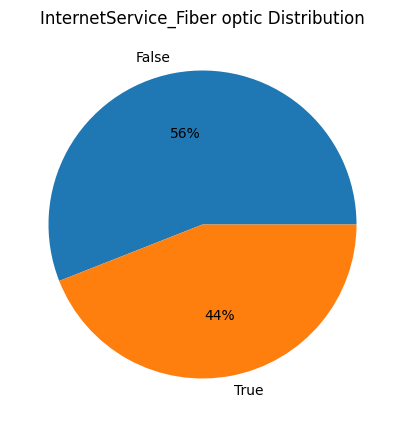

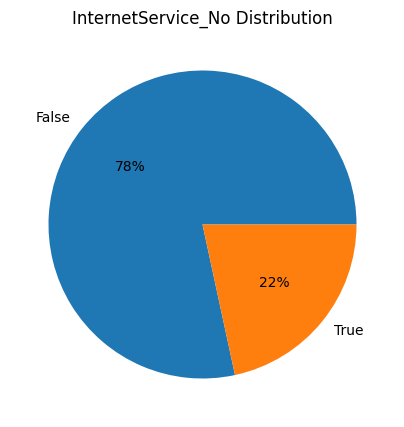

In [245]:
for col in multi_cols:
    data = df_clean[col].value_counts()  
    labels = data.index                  
    plt.figure(figsize=(5,5))
    plt.pie(data, labels=labels, autopct='%.0f%%')
    plt.title(f"{col} Distribution")
    plt.show()

In [246]:
for col in multi_cols:
    print(f"{col} vs Churn:")
    print(pd.crosstab(df_clean[col], df_clean['Churn'], normalize='index'))
    print("-"*30)

MultipleLines_No vs Churn:
Churn                    0         1
MultipleLines_No                    
False             0.720318  0.279682
True              0.749188  0.250812
------------------------------
MultipleLines_No phone service vs Churn:
Churn                                  0         1
MultipleLines_No phone service                    
False                           0.732525  0.267475
True                            0.750000  0.250000
------------------------------
MultipleLines_Yes vs Churn:
Churn                     0         1
MultipleLines_Yes                    
False              0.749323  0.250677
True               0.713515  0.286485
------------------------------
OnlineSecurity_No vs Churn:
Churn                     0         1
OnlineSecurity_No                    
False              0.884583  0.115417
True               0.582213  0.417787
------------------------------
OnlineSecurity_No internet service vs Churn:
Churn                                      0       

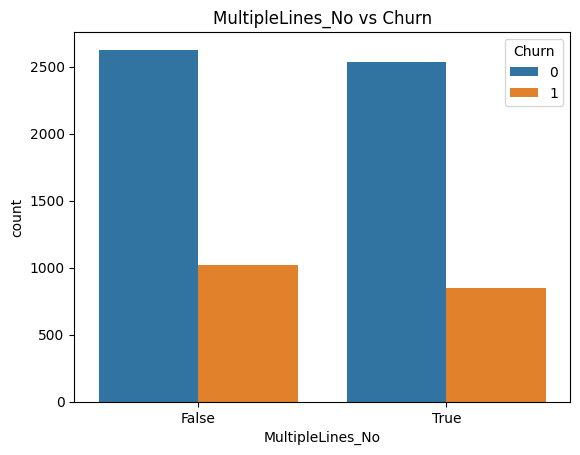

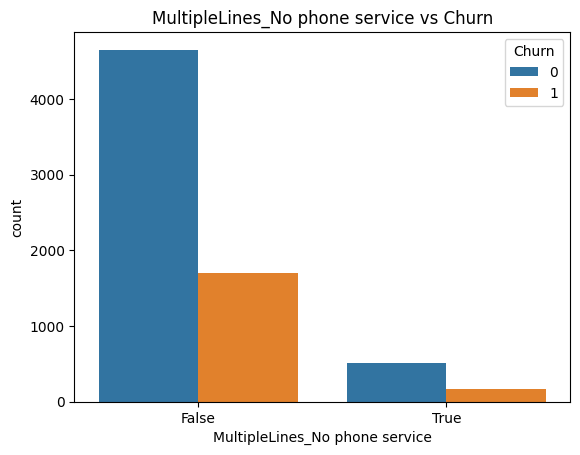

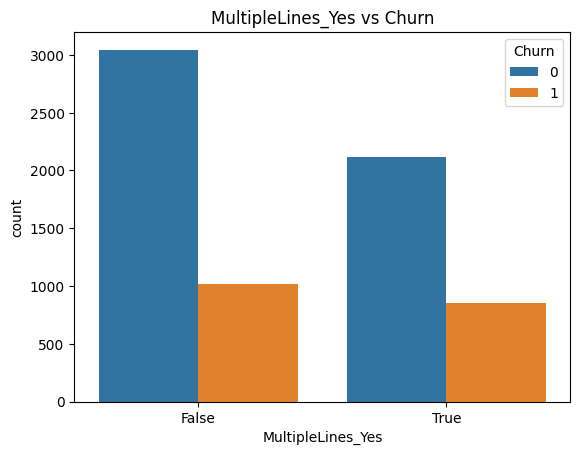

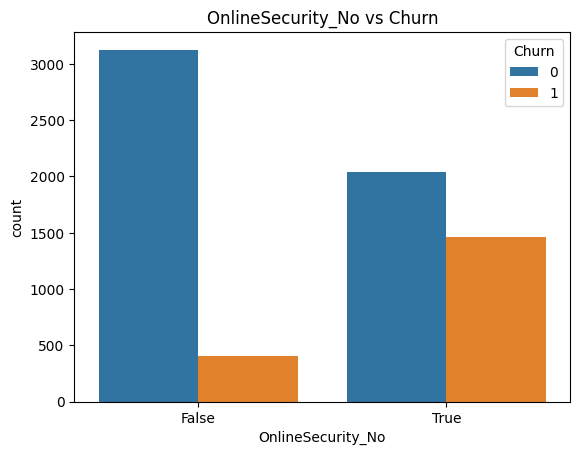

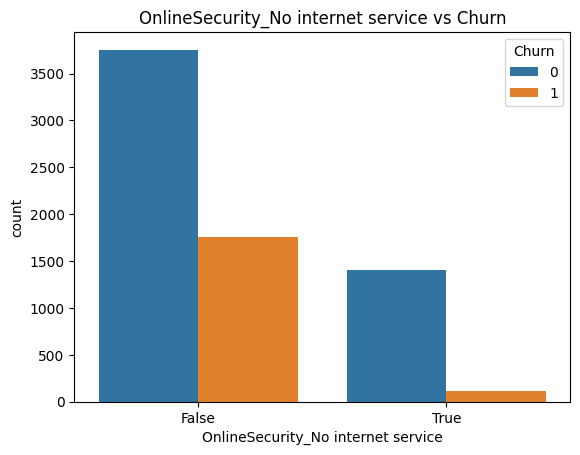

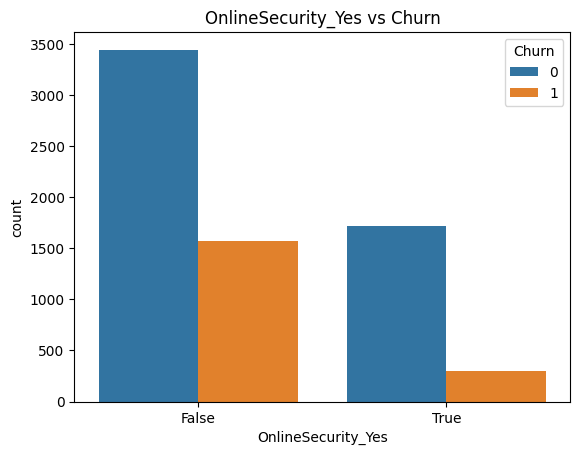

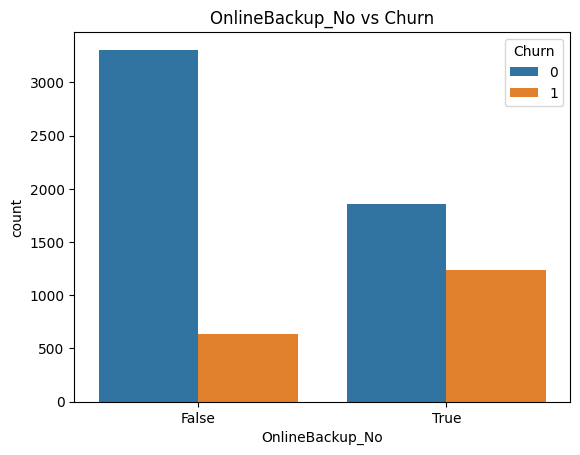

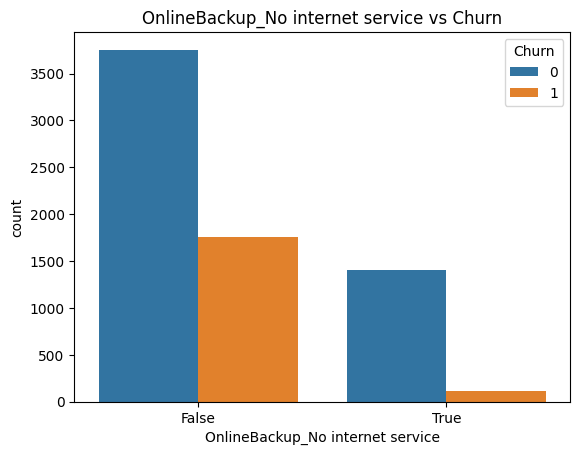

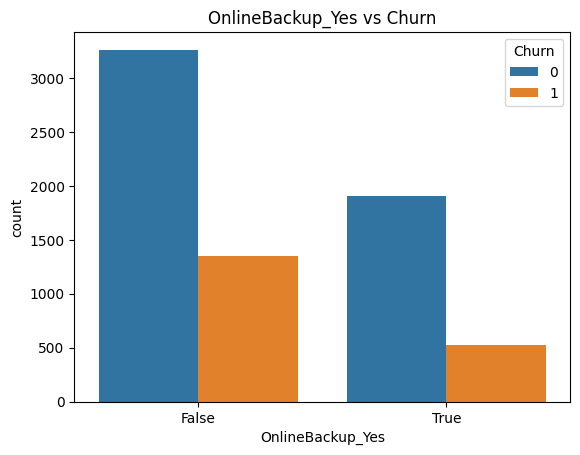

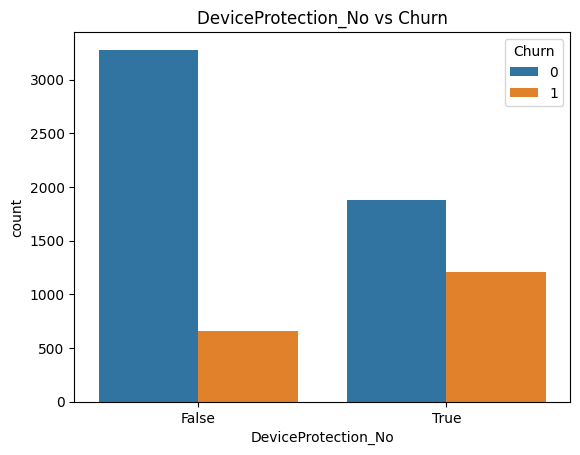

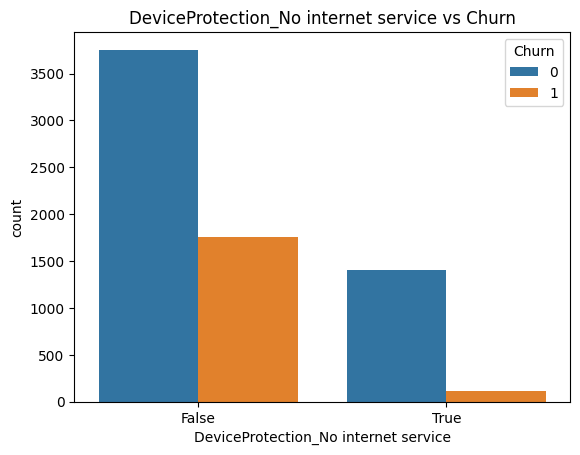

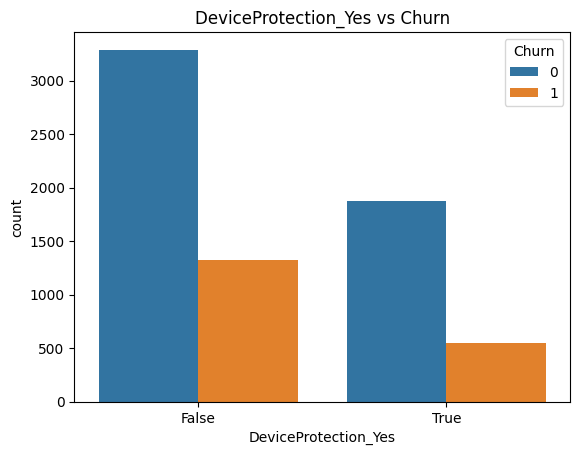

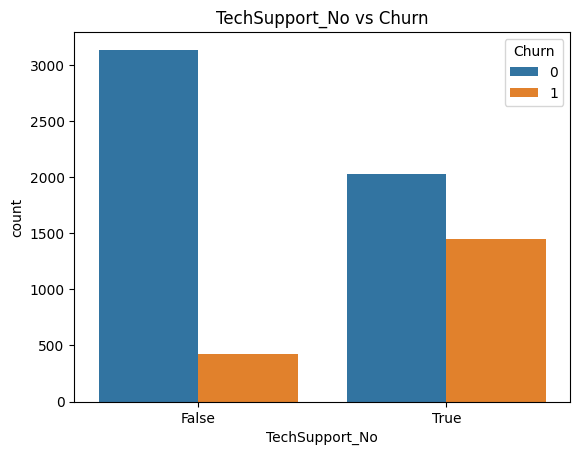

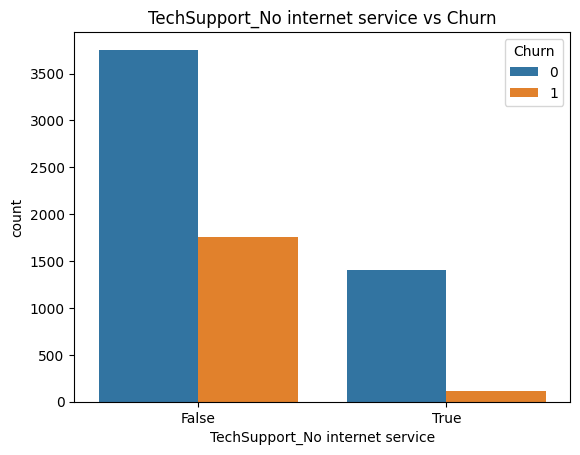

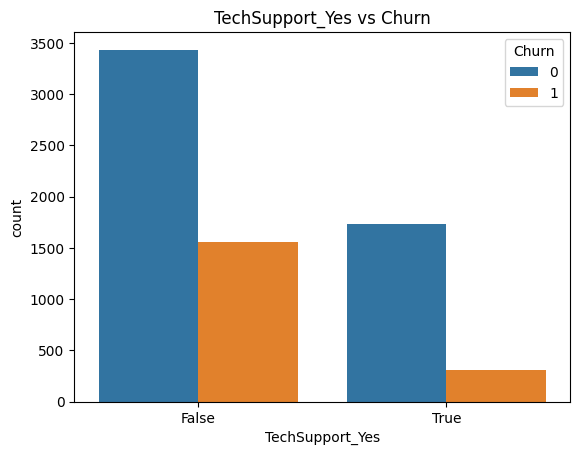

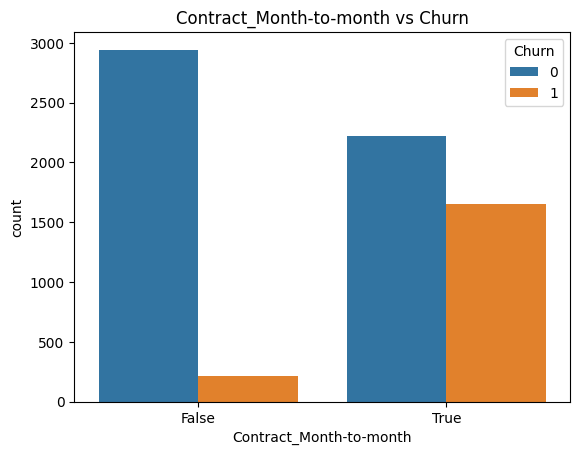

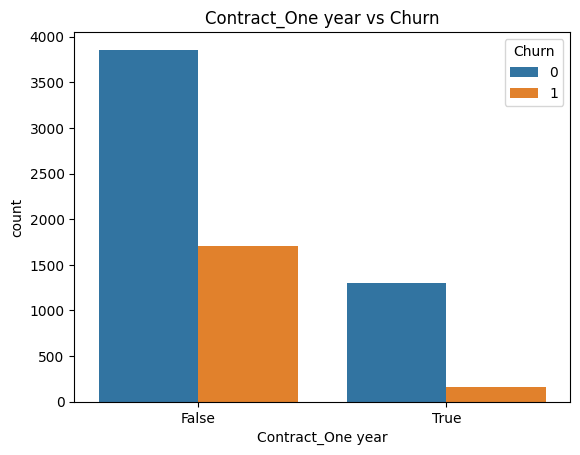

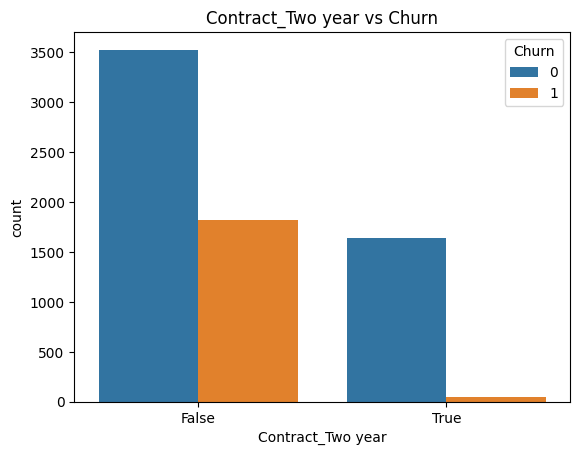

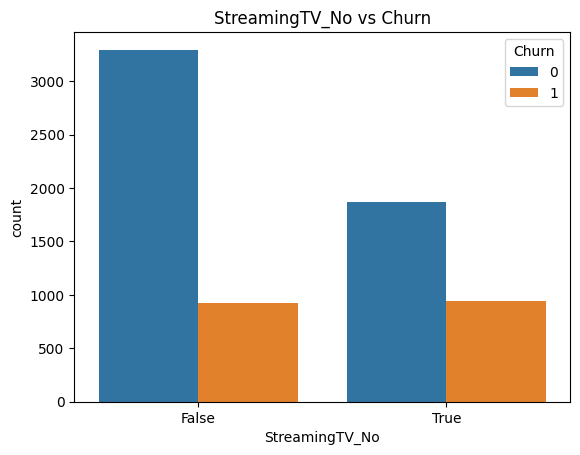

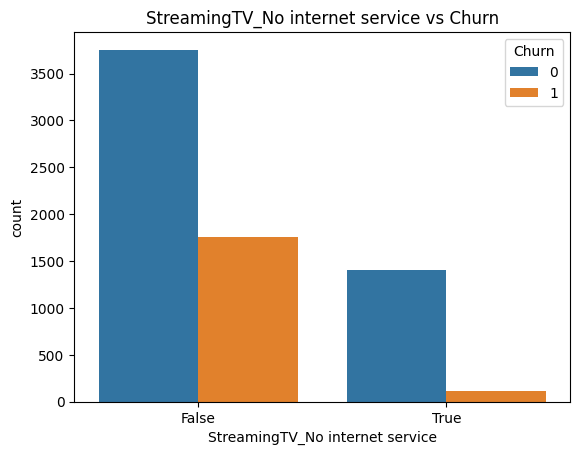

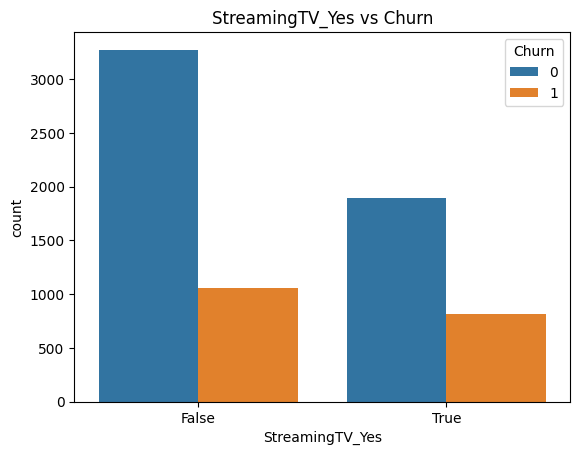

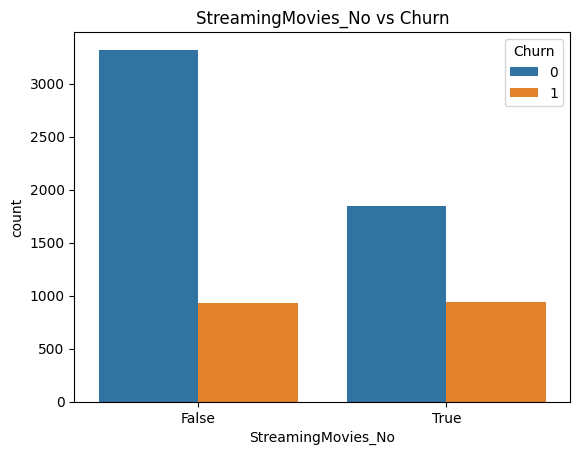

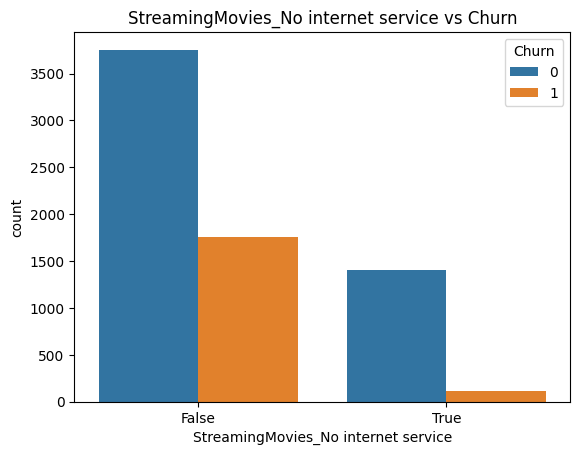

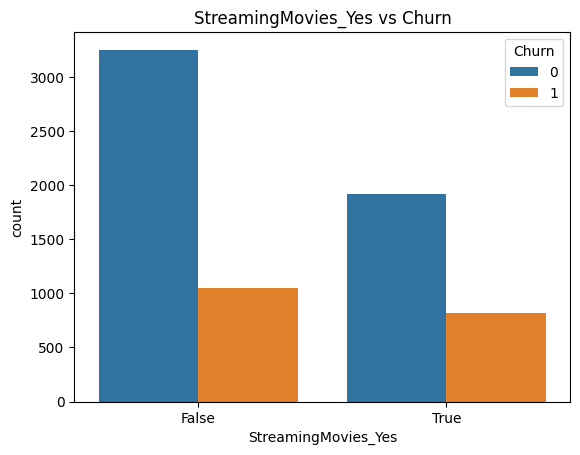

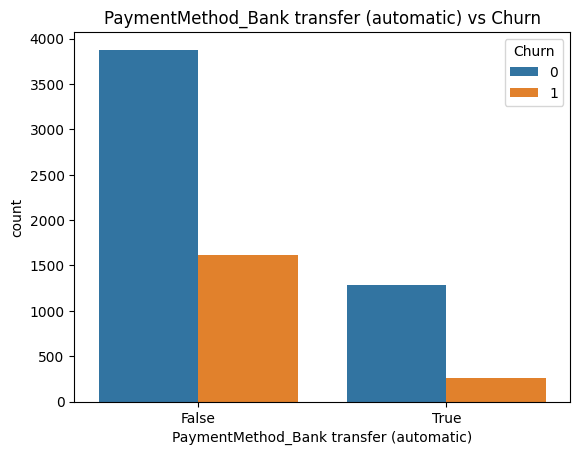

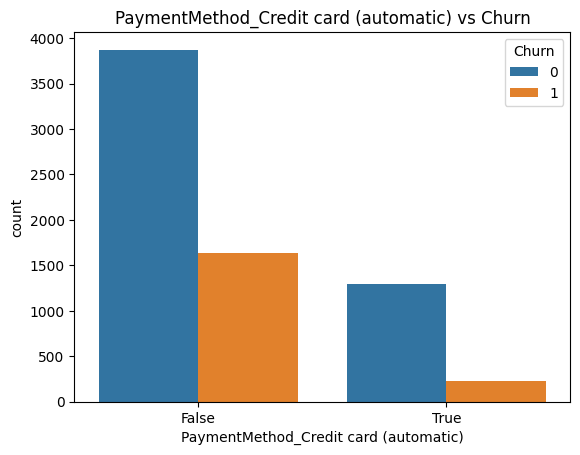

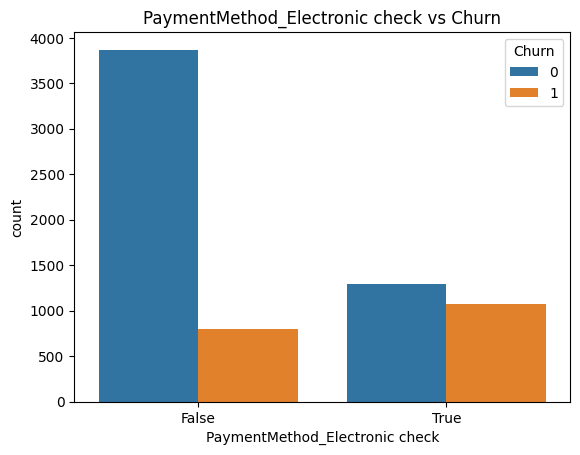

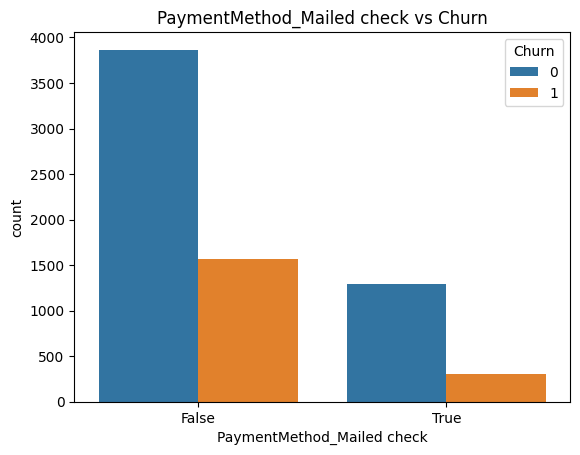

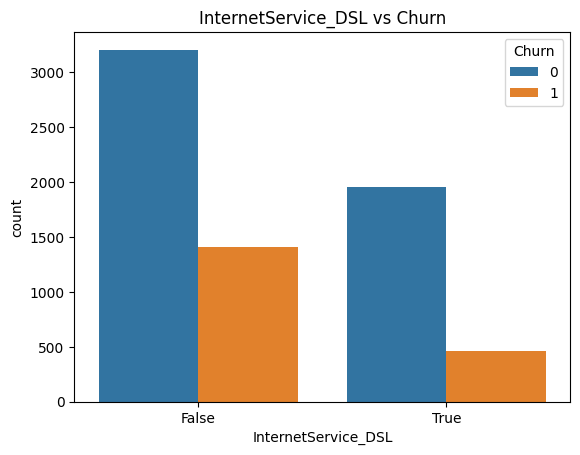

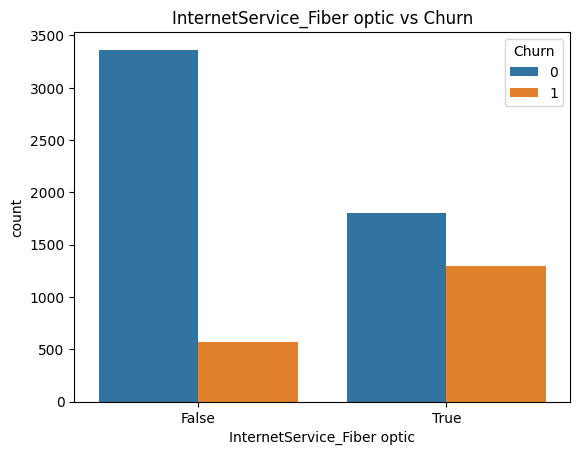

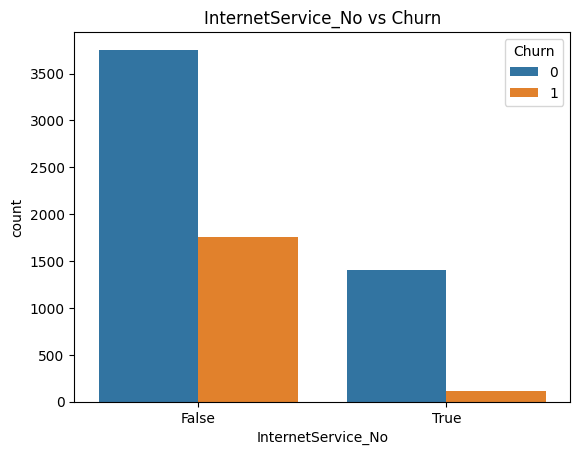

In [247]:
 for col in multi_cols:
    sns.countplot(x=col, hue='Churn', data=df_clean)
    plt.title(f"{col} vs Churn")
    plt.show()

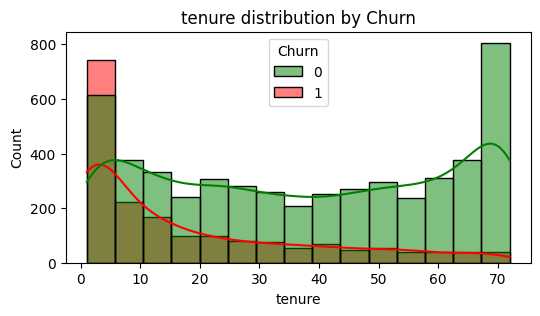

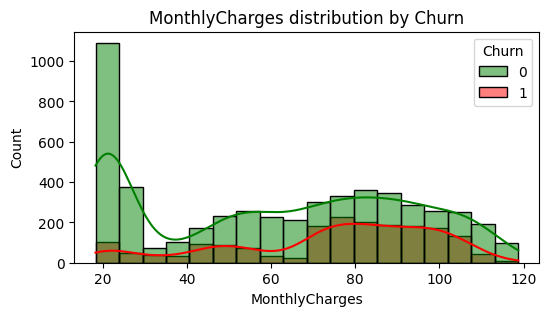

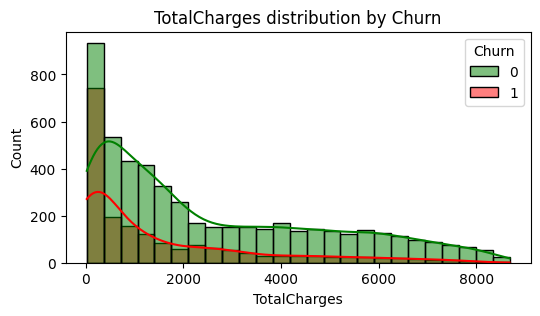

In [248]:

numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df_clean, x=col, hue='Churn', kde=True, palette=['green','red'], alpha=0.5)
    plt.title(f"{col} distribution by Churn")
    plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

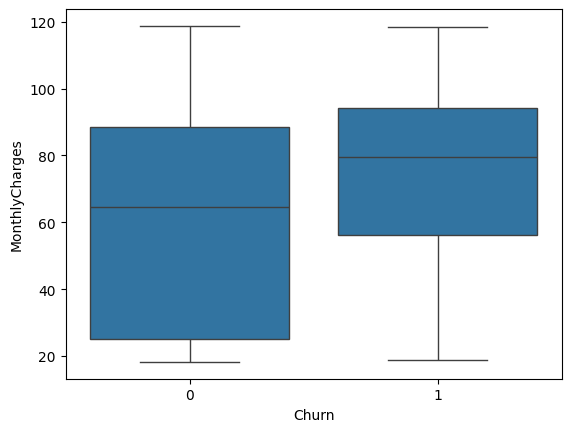

In [249]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean)

<Axes: xlabel='Churn', ylabel='tenure'>

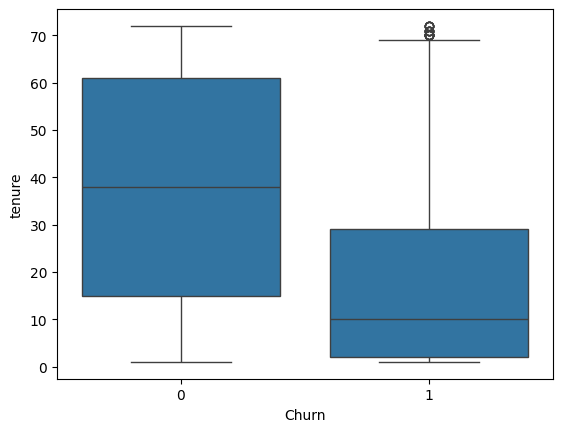

In [250]:
sns.boxplot(x='Churn', y='tenure', data=df_clean)

In [251]:
corr = df_clean.corr()
corr["Churn"]

SeniorCitizen                              0.150541
Partner                                   -0.149982
Dependents                                -0.163128
tenure                                    -0.354049
PhoneService                               0.011691
PaperlessBilling                           0.191454
MonthlyCharges                             0.192858
TotalCharges                              -0.199484
Churn                                      1.000000
MultipleLines_No                          -0.032654
MultipleLines_No phone service            -0.011691
MultipleLines_Yes                          0.040033
OnlineSecurity_No                          0.342235
OnlineSecurity_No internet service        -0.227578
OnlineSecurity_Yes                        -0.171270
OnlineBackup_No                            0.267595
OnlineBackup_No internet service          -0.227578
OnlineBackup_Yes                          -0.082307
DeviceProtection_No                        0.252056
DeviceProtec

In [252]:
df_clean.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
 

In [253]:
# Churn Rate
churn_rate = df_clean['Churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


In [254]:
# Monthly Recurring Revenue (MRR) lost due to churn
mrr_lost = df_clean[df_clean['Churn']==1]['MonthlyCharges'].sum()
print(f"MRR Lost due to Churn: ${mrr_lost:.2f}")

MRR Lost due to Churn: $139130.85


In [255]:
avg_tenure_churned = df_clean[df_clean['Churn']==1]['tenure'].mean()
print(f"Average Tenure of Churned Customers: {avg_tenure_churned:.2f} months")

Average Tenure of Churned Customers: 17.98 months


In [256]:
avg_clv_churned = df_clean[df_clean['Churn']==1]['TotalCharges'].mean()
print(f"Average CLV of Churned Customers: ${avg_clv_churned:.2f}")

Average CLV of Churned Customers: $1531.80


In [257]:
df_clean.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

In [258]:
plt.show()
plt.close()

# Summary of Analysis

## 1. Key Insights
- The overall churn rate is **26.58%**, indicating that approximately one-quarter of customers leave the service.
- Customers with **month-to-month contracts** have the highest churn rate (**42%**), compared to only **3%** for two-year contracts.
- **Higher monthly charges** are associated with increased churn, while **longer tenure** significantly reduces churn likelihood.
- Customers who have **partners or dependents** tend to stay longer.
- **Senior customers** and those using **paperless billing** show higher churn behavior.
- Customers without **internet service** are less likely to churn.
- Customers using **fiber optic services** exhibit higher churn rates.
- Customers subscribed to **multiple services** (e.g., online security, backup, streaming) are more likely to stay.

## 2. Key Performance Indicators (KPIs)

| KPI | Value|
|-----|-------|
| Overall Churn Rate | 26.58% |
| Monthly Recurring Revenue (MRR) | $139,130.85 |
| Average Tenure of Churned Customers | 17.98 months |
| Churn Rate (Two-Year Contract) | 3% |
| Churn Rate (Month-to-Month Contract) | 42% |
| Average Customer Lifetime Value (CLV) | \$1,531.80 |
## 3. Visual Insights
- Pie charts illustrate the distribution of customers across different services and payment methods.
- Stacked bar charts reveal that churn is highly concentrated among **month-to-month contract customers** and those with fewer subscribed services.

## 4. Conclusions & Recommendations
- Customers on **flexible (month-to-month) contracts** and with **higher monthly charges** are at the highest risk of churn.
- Introducing **long-term contract incentives** could significantly reduce churn rates.
- Offering **bundled services** and **loyalty programs** may improve customer retention.
- Special attention should be given to **fiber optic users** and **senior customers**, as they represent high-risk segments.